In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix , accuracy_score

In [2]:
print(torch.__version__)

2.14.0+cpu


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [37]:
print(torch.__version__)
print(torch.version.cuda)

2.14.0+cpu
None


In [ ]:
import sys
print(sys.executable)
exit()

c:\Users\Lokesh Bisen\AppData\Local\Programs\Python\Python310\python.exe


: 

In [39]:
import sys
print(sys.executable)

c:\Users\Lokesh Bisen\AppData\Local\Programs\Python\Python310\python.exe


In [5]:
data_dir = r"D:\Satellite_image_classification_CNN\data"
print(os.listdir(data_dir))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [6]:
dataset = datasets.ImageFolder(data_dir)

In [7]:
print(dataset.classes)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [8]:
print(dataset.class_to_idx)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [9]:
print("Total images:", len(dataset))

Total images: 27000


In [10]:
print(dataset[0])

(<PIL.Image.Image image mode=RGB size=64x64 at 0x1DFA2A31E10>, 0)


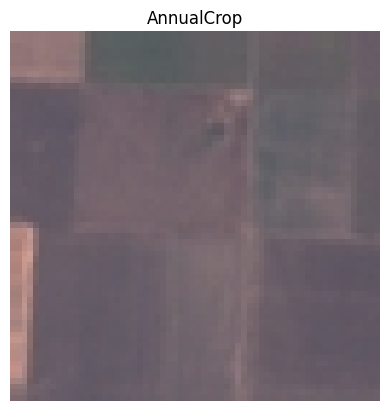

In [11]:
image, label = dataset[0]

plt.imshow(image)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

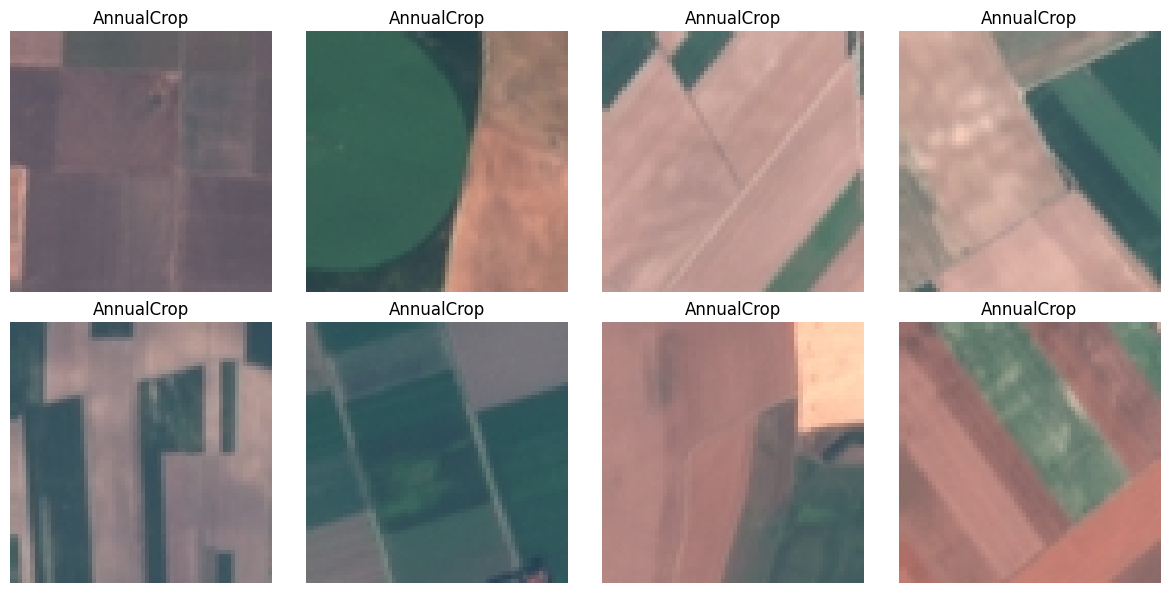

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image, label = dataset[i]

    ax.imshow(image)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
image, label = dataset[0]

print(image.size)

(64, 64)


In [14]:
IMG_SIZE = 128

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [16]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
full_dataset = datasets.ImageFolder(data_dir)

In [18]:
total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print(train_size)
print(val_size)
print(test_size)

18900
4050
4050


In [19]:
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

In [20]:
class TransformSubset(torch.utils.data.Dataset):

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
train_dataset = TransformSubset(
    train_dataset,
    transform=train_transform
)

val_dataset = TransformSubset(
    val_dataset,
    transform=test_transform
)

test_dataset = TransformSubset(
    test_dataset,
    transform=test_transform
)

In [22]:
BATCH_SIZE = 32

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [24]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [25]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [26]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [27]:
torch.Size([32, 3, 128, 128])
torch.Size([32])

torch.Size([32])

In [28]:
class SatelliteCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [29]:
num_classes = len(full_dataset.classes)

print(num_classes)

10


In [30]:
model = SatelliteCNN(num_classes)

model = model.to(device)

print(model)

SatelliteCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [31]:
criterion = nn.CrossEntropyLoss()

In [32]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [33]:
NUM_EPOCHS = 20

In [34]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [35]:
for epoch in range(NUM_EPOCHS):

    # -----------------------
    # Training
    # -----------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # -----------------------
    # Validation
    # -----------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predictions = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_accuracy = 100 * val_correct / val_total

    # Save history

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/20] Train Loss: 1.1499 Train Acc: 58.86% Val Loss: 0.8520 Val Acc: 69.83%
Epoch [2/20] Train Loss: 0.7818 Train Acc: 72.53% Val Loss: 0.6285 Val Acc: 76.99%


KeyboardInterrupt: 